<div style="background:#12355b;color:white;padding:16px 36px;border-radius:6px;">
<h1 style="margin:0;">Data Overview</h1>
<p style="margin:6px 0 0;">Vietnam Car Market | bonbanh.com | 33,848 listings | Power BI</p>
</div>

## **Table of Contents**

* [0. Setup & Imports](#0-setup-imports)
* [1. Load Raw Data](#1-load-raw-data)
* [2. Data Structure & Quality](#2-data-structure-quality)
  * [2.1. Column Schema & Datatypes](#21-column-schema-datatypes)
  * [2.2. Data Quality Overview](#22-data-quality-overview)
* [3. Market & Price Analysis](#3-market-price-analysis)
  * [3.1. Market Landscape](#31-market-landscape)
  * [3.2. Price Distribution Analysis](#32-price-distribution-analysis)
* [4. Missing Value Analysis](#4-missing-value-analysis)
* [5. Categorical Field Exploration](#5-categorical-field-exploration)
* [6. Numerical Fields & Outlier Detection](#6-numerical-fields-outlier-detection)
* [7. Fuel Type Trend Analysis](#7-fuel-type-trend-analysis)
* [8. Dashboard KPI Pre-Validation](#8-dashboard-kpi-pre-validation)
* [9. Star Schema Architecture Review](#9-star-schema-architecture-review)

<a id="0-setup-imports"></a>
## **0. Setup & Imports**

**Nội dung:**
Thiết lập môi trường làm việc, import toàn bộ thư viện phân tích và trực quan hóa cần dùng trong notebook. Cấu hình hiển thị cho Pandas và Seaborn, định nghĩa đường dẫn đến thư mục `data/raw/` và `data/processed/`, đồng thời xác nhận sự tồn tại của ba file dữ liệu chính trước khi bắt đầu phân tích.

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Configure display and plot style
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 40)
pd.set_option("display.max_colwidth", 80)
pd.set_option("display.float_format", "{:,.2f}".format)
sns.set_theme(style="whitegrid", palette="muted")

# Define project paths
PROJECT_ROOT = Path("..").resolve()
RAW_DIR      = PROJECT_ROOT / "data" / "raw"
PROC_DIR     = PROJECT_ROOT / "data" / "processed"

RAW_PATH  = RAW_DIR  / "car_detail.csv"
PROC_PATH = PROC_DIR / "car_detail_processed.csv"
FACT_PATH = PROC_DIR / "fact_car_listings.csv"

print(f"Thư mục gốc     : {PROJECT_ROOT}")
print(f"File thô        : {RAW_PATH}")
print(f"File đã xử lý   : {PROC_PATH}")
print(f"Bảng fact       : {FACT_PATH}")
print()
print(f"Raw tồn tại       : {RAW_PATH.exists()}")
print(f"Processed tồn tại : {PROC_PATH.exists()}")
print(f"Fact tồn tại      : {FACT_PATH.exists()}")

assert RAW_PATH.exists(),  f"Không tìm thấy file: {RAW_PATH}"
assert PROC_PATH.exists(), f"Không tìm thấy file: {PROC_PATH}"
assert FACT_PATH.exists(), f"Không tìm thấy file: {FACT_PATH}"

Thư mục gốc     : D:\TU HOC\DV_Final
File thô        : D:\TU HOC\DV_Final\data\raw\car_detail.csv
File đã xử lý   : D:\TU HOC\DV_Final\data\processed\car_detail_processed.csv
Bảng fact       : D:\TU HOC\DV_Final\data\processed\fact_car_listings.csv

Raw tồn tại       : True
Processed tồn tại : True
Fact tồn tại      : True


**Nhận xét:**
- Toàn bộ thư viện được import tập trung tại cell này. Không có import nào được thực hiện ở các cell phía sau trong suốt notebook.
- Cả ba file dữ liệu chính đều xác nhận tồn tại: file thô gốc `car_detail.csv`, file đã làm sạch `car_detail_processed.csv` và bảng fact `fact_car_listings.csv` cho mô hình Star Schema.
- Đường dẫn được xây dựng động qua `pathlib.Path` thay vì hardcode chuỗi, giúp notebook chạy đúng trên bất kỳ máy nào clone repository mà không cần chỉnh sửa thủ công.


<a id="1-load-raw-data"></a>
## **1. Load Raw Data**

**Nội dung:**
Nạp dữ liệu thô từ `car_detail.csv` vào DataFrame chính. Hiển thị kích thước tổng thể (số dòng, số cột), liệt kê đầy đủ tên 21 cột theo thứ tự gốc và 5 dòng đầu để có cái nhìn ban đầu về cấu trúc và kiểu giá trị của từng trường.

In [2]:
# Load raw dataset
df = pd.read_csv(RAW_PATH, encoding="utf-8", low_memory=False)

print(f"Kích thước tập dữ liệu: {df.shape[0]:,} dòng  x  {df.shape[1]} cột")
print()
print("Danh sách cột:")
for i, col in enumerate(df.columns, 1):
    print(f"  {i:>2}. {col}")

print()
print("5 dòng đầu tiên:")
display(df.head(5))

Kích thước tập dữ liệu: 33,848 dòng  x  21 cột

Danh sách cột:
   1. Mã tin
   2. Xuất xứ
   3. Tình trạng
   4. Dòng xe
   5. Số Km đã đi
   6. Màu ngoại thất
   7. Màu nội thất
   8. Số cửa
   9. Số chỗ ngồi
  10. Động cơ
  11. Hệ thống nạp nhiên liệu
  12. Hộp số
  13. Dẫn động
  14. Tiêu thụ nhiên liệu
  15. Mô tả
  16. Hãng
  17. Grade
  18. Năm sản xuất
  19. Tên xe
  20. Giá
  21. URL

5 dòng đầu tiên:


,Mã tin,Xuất xứ,Tình trạng,Dòng xe,Số Km đã đi,Màu ngoại thất,Màu nội thất,Số cửa,Số chỗ ngồi,Động cơ,Hệ thống nạp nhiên liệu,Hộp số,Dẫn động,Tiêu thụ nhiên liệu,Mô tả,Hãng,Grade,Năm sản xuất,Tên xe,Giá,URL
0,17042,Lắp ráp trong nước,Xe mới,Truck,0 Km,Trắng,Ghi,2 cửa,2 chỗ,Xăng\t1.0 L,NaN,Số tay,RFD - Dẫn động cầu sau,L/100Km,Super Carry Truck 5 tạ thùng lửng được trang bị Động cơ dung tích lớn vận hà...,Suzuki,Super Carry Truck,"2,022.00",Xe Suzuki Super Carry Truck 1.0 MT 2022,249 Triệu,https://bonbanh.com/xe-suzuki-super_carry_truck-1.0-mt-2022-17042
1,53794,Nhập khẩu,Xe mới,SUV,0 Km,Đen,Đen,5 cửa,7 chỗ,Xăng\t3.4 L,NaN,Số tự động,AWD - 4 bánh toàn thời gian,10\tL/100Km,"Toyota LANDCRUISER 300 mới, nhập khẩu Nhật Bản mới 100% nội thất 2 màu Đen, ...",Toyota,Land Cruiser,"2,022.00",Xe Toyota Land Cruiser 3.5 V6 2022,4 Tỷ 286 Triệu,https://bonbanh.com/xe-toyota-land_cruiser-3.5-v6-2022-53794
2,73954,Lắp ráp trong nước,Xe mới,Crossover,0 Km,Bạc,Nâu,5 cửa,8 chỗ,Xăng\t2.0 L,NaN,Số tự động,RFD - Dẫn động cầu sau,L/100Km,**Hỗ trợ lệ phí trước bạ trị giá 15 triệu đồng- Màu trắng ngọc trai: + 8.000...,Toyota,Innova,"2,023.00",Xe Toyota Innova G 2.0 AT 2023,885 Triệu,https://bonbanh.com/xe-toyota-innova-g-2.0-at-2023-73954
3,74150,Nhập khẩu,Xe mới,SUV,0 Km,Trắng,Đen,5 cửa,5 chỗ,Xăng\t1.8 L,NaN,Số tự động,FWD - Dẫn động cầu trước,L/100Km,"- 2 màu nội thất: đen, đỏ nâu- Xe có sẵn giao ngay, đủ màu- Hỗ trợ trả góp l...",Toyota,Corolla Cross,"2,023.00",Xe Toyota Corolla Cross 1.8G 2023,754 Triệu,https://bonbanh.com/xe-toyota-corolla_cross-1.8g-2023-74150
4,87573,Lắp ráp trong nước,Xe mới,Crossover,0 Km,Bạc,Ghi,5 cửa,8 chỗ,Xăng\t2.0 L,NaN,Số tự động,RFD - Dẫn động cầu sau,L/100Km,"Toyota Innova G mới 100%Trang bị động cơ 2.0. Động cơ xăng, VVT-i kép, 4 xy ...",Toyota,Innova,"2,022.00",Xe Toyota Innova G 2.0 AT 2022,850 Triệu,https://bonbanh.com/xe-toyota-innova-g-2.0-at-2022-87573


**Nhận xét:**
* **Kích thước tập dữ liệu:** Tập dữ liệu thô chứa *33,848 dòng* và *21 cột*, được crawl từ bonbanh.com.

* **Khoá chính:** Cột `Mã tin` đóng vai trò định danh cho từng tin đăng, kiểm tra sơ bộ cho thấy có *17 Mã tin bị trùng* do lỗi thu thập dữ liệu và sẽ được xử lý trong bước preprocessing.

* **Phân nhóm cột:** 21 cột có thể nhóm thành bốn nhóm chức năng:
  * *Định danh:* `Mã tin`, `Tên xe`, `URL`, `Hãng`, `Grade`
  * *Phân loại xe:* `Xuất xứ`, `Tình trạng`, `Dòng xe`, `Động cơ`, `Hộp số`, `Dẫn động`, `Hệ thống nạp nhiên liệu`
  * *Đặc tính vật lý:* `Màu ngoại thất`, `Màu nội thất`, `Số cửa`, `Số chỗ ngồi`
  * *Số liệu đo lường:* `Năm sản xuất`, `Số Km đã đi`, `Tiêu thụ nhiên liệu`, `Giá`
  
* **Cột Giá:** Được lưu dạng chuỗi văn bản (ví dụ: `"249 Triệu"`, `"4 Tỷ 286 Triệu"`), chưa phải kiểu số và cần parse lại trong bước tiền xử lý.

<a id="2-data-structure-quality"></a>

## **2. Data Structure & Quality**

<a id="21-column-schema-datatypes"></a>
## **2.1. Column Schema & Datatypes**

**Nội dung:**
Khảo sát kiểu dữ liệu, số dòng có giá trị hợp lệ (non-null), tỷ lệ rỗng và số lượng giá trị duy nhất của từng cột, nhằm hiểu rõ bức tranh cấu trúc tổng quan trước khi phân tích. Kết quả được trình bày theo hai bảng: toàn bộ 21 cột theo thứ tự gốc và top 7 cột có tỷ lệ rỗng cao nhất.

In [3]:
# Build column schema summary table
schema = pd.DataFrame({
    "Cột"              : df.columns,
    "Kiểu dữ liệu"    : df.dtypes.astype(str).values,
    "Dòng có giá trị" : df.notna().sum().values,
    "% Rỗng"          : (df.isna().mean().values * 100).round(2),
    "Giá trị duy nhất": [df[c].nunique(dropna=True) for c in df.columns],
})

print("Cấu trúc toàn bộ 21 cột:")
display(schema)

print("\nTop 7 cột có tỷ lệ rỗng cao nhất:")
display(
    schema.sort_values("% Rỗng", ascending=False)
          .head(7)
          .reset_index(drop=True)
)

Cấu trúc toàn bộ 21 cột:


,Cột,Kiểu dữ liệu,Dòng có giá trị,% Rỗng,Giá trị duy nhất
0,Mã tin,int64,33848,0.00,33831
1,Xuất xứ,str,33848,0.00,2
2,Tình trạng,str,33848,0.00,2
3,Dòng xe,str,33848,0.00,10
4,Số Km đã đi,str,33052,2.35,2024
5,Màu ngoại thất,str,33848,0.00,18
6,Màu nội thất,str,33848,0.00,18
7,Số cửa,str,33848,0.00,12
8,Số chỗ ngồi,str,33848,0.00,26
9,Động cơ,str,33848,0.00,140



Top 7 cột có tỷ lệ rỗng cao nhất:


,Cột,Kiểu dữ liệu,Dòng có giá trị,% Rỗng,Giá trị duy nhất
0,Hệ thống nạp nhiên liệu,str,6745,80.07,879
1,Tiêu thụ nhiên liệu,str,30652,9.44,76
2,Dẫn động,str,30652,9.44,6
3,Hộp số,str,30652,9.44,4
4,Số Km đã đi,str,33052,2.35,2024
5,Năm sản xuất,float64,33816,0.09,36
6,Tình trạng,str,33848,0.00,2


**Nhận xét:**
* **Kiểu dữ liệu:** 19 trên 21 cột được Pandas nhận diện là `object` (chuỗi văn bản). Chỉ hai cột có kiểu số ngay từ đầu: `Mã tin` (`int64`) và `Năm sản xuất` (`float64`). Toàn bộ các cột số liệu còn lại như `Giá`, `Số Km đã đi`, `Số cửa`, `Số chỗ ngồi` đều lưu dạng chuỗi vì kèm theo đơn vị văn bản (ví dụ: `"5 cửa"`, `"0 Km"`), cần parse lại trong bước preprocessing.

* **Cột rỗng đáng chú ý:** `Hệ thống nạp nhiên liệu` có tỷ lệ rỗng cực cao là *80.07%* (chỉ 6,745 trên 33,848 dòng có giá trị). Nhóm ba cột `Hộp số`, `Dẫn động` và `Tiêu thụ nhiên liệu` cùng có tỷ lệ rỗng *9.44%*, ba cột này liên quan theo logic skip trong form đăng tin, người đăng bỏ qua sẽ khiến cả ba cùng trống.

* **Cột đầy đủ:** 12 cột có tỷ lệ rỗng bằng 0, bao gồm tất cả các trường phân loại chính như `Hãng`, `Dòng xe`, `Tình trạng`, `Xuất xứ`, `Màu ngoại thất`, `Màu nội thất`. Đây là nhóm cột tin cậy nhất để làm trục slicer trong Power BI.

* **Giá trị duy nhất bất thường:** Cột `Số cửa` có 12 giá trị duy nhất và `Số chỗ ngồi` có 26, cao hơn nhiều so với kỳ vọng vì dữ liệu lưu dạng văn bản có thể chứa lỗi nhập liệu (ví dụ: `"45 cửa"`, `"54 cửa"`). Cột `Mô tả` có 31,964 giá trị duy nhất phản ánh nội dung mô tả tự do của từng tin đăng.

* **Primary Key:** `Mã tin` có 33,831 giá trị duy nhất trên 33,848 dòng, tức có *17 Mã tin bị trùng*. Tỷ lệ này chỉ 0.05% nhưng cần loại bỏ trước khi xây dựng bảng fact để đảm bảo tính toàn vẹn trong Star Schema.

<a id="22-survey-schema-question-types"></a>
## **2.2. Survey Schema Question Types**

Đánh giá chất lượng tổng thể của tập dữ liệu thô theo bốn chiều: tỷ lệ rỗng toàn bảng, các cột chứa giá trị bất thường hoặc lỗi nhập liệu (mixed types), số dòng trùng khóa chính `Mã tin`, và các mẫu chuỗi không chuẩn trong cột `Giá`. Kết quả ở bước này làm cơ sở để đánh giá mức độ tin cậy của dữ liệu trước khi tiến hành phân tích chuyên sâu.

In [4]:
# 1. Overall missing rate 
total_cells   = df.shape[0] * df.shape[1]
missing_cells = int(df.isna().sum().sum())
overall_miss  = missing_cells / total_cells * 100

print("Chất lượng dữ liệu tổng quan:")
print(f"  Tổng số ô          : {total_cells:,}")
print(f"  Số ô rỗng          : {missing_cells:,}")
print(f"  Tỷ lệ rỗng tổng thể: {overall_miss:.2f}%")

# 2. Duplicate primary key
dup_count  = int(df.duplicated(subset=["Mã tin"]).sum())
uniq_count = df["Mã tin"].nunique()
print(f"\nKiểm tra khoá chính Mã tin:")
print(f"  Tổng dòng          : {len(df):,}")
print(f"  Mã tin duy nhất    : {uniq_count:,}")
print(f"  Dòng trùng Mã tin  : {dup_count}")

# 3. Giá string patterns
gia_ty     = int(df["Giá"].str.contains("Tỷ",    na=False).sum())
gia_trieu  = int(df["Giá"].str.contains("Triệu", na=False).sum())
print(f"\nPhân tích cột Giá (kiểu chuỗi):")
print(f"  Dòng chứa đơn vị 'Tỷ'   : {gia_ty:,}")
print(f"  Dòng chứa đơn vị 'Triệu': {gia_trieu:,}")
print(f"  Ví dụ giá trị thô        : {df['Giá'].iloc[0]}  |  {df['Giá'].iloc[1]}")

#  4. Columns with suspicious unique counts (mixed types) 
suspicious_cols = {
    "Số cửa"    : df["Số cửa"].value_counts(),
    "Số chỗ ngồi": df["Số chỗ ngồi"].value_counts(),
}
for col, vc in suspicious_cols.items():
    valid   = vc[vc.index.str.match(r"^\d+ ")].sum()
    invalid = vc[~vc.index.str.match(r"^\d+ ")].sum()
    print(f"\nKiểm tra cột '{col}' (total unique={len(vc)}):")
    print(f"  Giá trị hợp lệ  (dạng 'X ...'): {valid:,} dòng")
    print(f"  Giá trị bất thường             : {invalid:,} dòng")
    # Show suspicious values
    bad_vals = vc[vc.index.str.match(r"^[4-9][0-9]+ ")]
    if not bad_vals.empty:
        print(f"  Các giá trị nghi ngờ lỗi      : {bad_vals.to_dict()}")

#  5. Năm sản xuất range and nulls 
year_min  = int(df["Năm sản xuất"].min())
year_max  = int(df["Năm sản xuất"].max())
year_null = int(df["Năm sản xuất"].isna().sum())
print(f"\nCột Năm sản xuất:")
print(f"  Khoảng hợp lệ : {year_min} – {year_max}")
print(f"  Dòng null     : {year_null}")

#  6. Số Km đã đi sample 
km_zero = int((df["Số Km đã đi"] == "0 Km").sum())
km_null = int(df["Số Km đã đi"].isna().sum())
print(f"\nCột Số Km đã đi:")
print(f"  Dòng '0 Km' (xe mới)  : {km_zero:,}")
print(f"  Dòng null             : {km_null:,}")
print(f"  Top 5 giá trị phổ biến:")
for val, cnt in df["Số Km đã đi"].value_counts().head(5).items():
    print(f"    {val:<15} {cnt:>5,} dòng")

Chất lượng dữ liệu tổng quan:
  Tổng số ô          : 710,808
  Số ô rỗng          : 37,519
  Tỷ lệ rỗng tổng thể: 5.28%

Kiểm tra khoá chính Mã tin:
  Tổng dòng          : 33,848
  Mã tin duy nhất    : 33,831
  Dòng trùng Mã tin  : 17

Phân tích cột Giá (kiểu chuỗi):
  Dòng chứa đơn vị 'Tỷ'   : 9,125
  Dòng chứa đơn vị 'Triệu': 33,731
  Ví dụ giá trị thô        : 249 Triệu  |  4 Tỷ 286 Triệu

Kiểm tra cột 'Số cửa' (total unique=12):
  Giá trị hợp lệ  (dạng 'X ...'): 33,848 dòng
  Giá trị bất thường             : 0 dòng
  Các giá trị nghi ngờ lỗi      : {'45 cửa': 4, '54 cửa': 2, '44 cửa': 1, '42 cửa': 1}

Kiểm tra cột 'Số chỗ ngồi' (total unique=26):
  Giá trị hợp lệ  (dạng 'X ...'): 33,848 dòng
  Giá trị bất thường             : 0 dòng
  Các giá trị nghi ngờ lỗi      : {'47 chỗ': 4, '42 chỗ': 1, '44 chỗ': 1, '46 chỗ': 1}

Cột Năm sản xuất:
  Khoảng hợp lệ : 1990 – 2025
  Dòng null     : 32

Cột Số Km đã đi:
  Dòng '0 Km' (xe mới)  : 10,564
  Dòng null             : 796
  Top 5 giá trị

**Nhận xét:**
* **Chất lượng tổng thể:** Tỷ lệ rỗng toàn bảng chỉ *5.28%* (37,519 ô trên 710,808 ô). Phần lớn lỗi rỗng tập trung ở một cột duy nhất là `Hệ thống nạp nhiên liệu` (80.07%), còn lại các cột phân loại và đo lường quan trọng đều đầy đủ.

* **Khoá chính không hoàn toàn duy nhất:** Có *17 dòng bị trùng `Mã tin`* (chiếm 0.05%), nhiều khả năng do crawler thu thập lại cùng một tin đăng ở các lần chạy khác nhau. Cần `drop_duplicates(subset=["Mã tin"], keep="first")` trước khi xây dựng bảng fact.

* **Cột `Giá` lưu chuỗi hỗn hợp:** 33,731 dòng dùng đơn vị "Triệu" và 9,125 dòng dùng "Tỷ ... Triệu". Đây là định dạng văn bản tự nhiên của bonbanh.com, cần regex để parse sang số thực (triệu VND). File `car_detail_processed.csv` đã thực hiện bước này và lưu kết quả vào cột `Giá (triệu VND)`.

* **Cột `Số cửa` và `Số chỗ ngồi` chứa lỗi nhập liệu:** Xuất hiện các giá trị phi lý như `"45 cửa"`, `"54 cửa"`, `"47 chỗ"`, `"29 chỗ"`, nhiều khả năng do người dùng nhập sai hoặc hệ thống bonbanh.com ghép nhầm trường. Tổng cộng 12 giá trị duy nhất cho `Số cửa` và 26 giá trị cho `Số chỗ ngồi`, trong khi thực tế chỉ cần 4–5 loại hợp lệ. Cột `Số cửa sạch` và `Số chỗ ngồi sạch` trong processed data đã lọc và chuẩn hoá về số nguyên.

* **Cột `Số Km đã đi`:** 10,564 dòng có giá trị `"0 Km"`, đây là xe mới hoặc xe chưa lăn bánh, không phải dữ liệu lỗi. 796 dòng null cần được xử lý riêng trong bước phân tích số km.

* **Cột `Năm sản xuất`:** Khoảng hợp lệ từ 1990 đến 2025, chỉ có 32 dòng null (0.09%), đây là trường đầy đủ nhất trong nhóm số liệu đo lường.

<a id="3-market-price-analysis"></a>

## **3. Market & Price Analysis**

<a id="31-market-landscape"></a>
## **3.1. Market Landscape**

Khảo sát cơ cấu thị trường xe ô tô qua năm biến phân loại chính: hãng sản xuất (`Hãng`), loại thân xe (`Dòng xe`), tình trạng xe (`Tình trạng`), xuất xứ (`Xuất xứ`) và năm sản xuất (`Năm sản xuất`). Dữ liệu từ section này cung cấp số liệu nền trực tiếp cho Tab 1: Bức Tranh Thị Trường trong dashboard Power BI.

In [5]:
def top_categories(data, column, n=15):
    """Compute value counts with percentage for a categorical column."""
    return (
        data[column]
        .fillna("Không rõ")
        .value_counts()
        .head(n)
        .rename_axis(column)
        .reset_index(name="Số tin")
        .assign(Tỷ_lệ=lambda x: (x["Số tin"] / len(data) * 100).round(2))
    )

# Top 15 brands by listing count
print(f"Tổng số hãng xe duy nhất: {df['Hãng'].nunique()}")
print(f"Tổng số model (Grade)    : {df['Grade'].nunique()}")
print(f"Tổng số tên xe           : {df['Tên xe'].nunique()}")
print()
print("Top 15 hãng xe theo số tin đăng:")
display(top_categories(df, "Hãng", 15))

# Body type distribution
print("\nPhân bố loại thân xe (Dòng xe):")
display(top_categories(df, "Dòng xe", 10))

# Vehicle condition distribution
print("\nPhân bố Tình trạng xe:")
display(top_categories(df, "Tình trạng", 5))

# Origin distribution
print("\nPhân bố Xuất xứ:")
display(top_categories(df, "Xuất xứ", 5))

# Year of manufacture distribution (top 15 most recent years)
year_dist = (
    df["Năm sản xuất"]
    .dropna()
    .astype(int)
    .value_counts()
    .sort_index(ascending=False)
    .head(15)
    .reset_index()
)
year_dist.columns = ["Năm sản xuất", "Số tin"]
year_dist["Tỷ lệ (%)"] = (year_dist["Số tin"] / len(df) * 100).round(2)
print("\nPhân bố theo Năm sản xuất (15 năm gần nhất):")
display(year_dist)

Tổng số hãng xe duy nhất: 91
Tổng số model (Grade)    : 569
Tổng số tên xe           : 7912

Top 15 hãng xe theo số tin đăng:


,Hãng,Số tin,Tỷ_lệ
0,Toyota,5861,17.32
1,Hyundai,3897,11.51
2,Ford,3719,10.99
3,Mercedes Benz,3376,9.97
4,Kia,3258,9.63
5,Mazda,2447,7.23
6,Mitsubishi,1540,4.55
7,Honda,1322,3.91
8,Lexus,1023,3.02
9,Chevrolet,802,2.37



Phân bố loại thân xe (Dòng xe):


,Dòng xe,Số tin,Tỷ_lệ
0,SUV,12289,36.31
1,Sedan,10777,31.84
2,Crossover,3132,9.25
3,Hatchback,2997,8.85
4,Bán tải / Pickup,2536,7.49
5,Van/Minivan,1388,4.10
6,Truck,432,1.28
7,Coupe,182,0.54
8,Convertible/Cabriolet,105,0.31
9,Wagon,10,0.03



Phân bố Tình trạng xe:


,Tình trạng,Số tin,Tỷ_lệ
0,Xe đã dùng,26982,79.72
1,Xe mới,6866,20.28



Phân bố Xuất xứ:


,Xuất xứ,Số tin,Tỷ_lệ
0,Lắp ráp trong nước,19645,58.04
1,Nhập khẩu,14203,41.96



Phân bố theo Năm sản xuất (15 năm gần nhất):


,Năm sản xuất,Số tin,Tỷ lệ (%)
0,2025,1597,4.72
1,2024,1599,4.72
2,2023,4006,11.84
3,2022,3737,11.04
4,2021,2753,8.13
5,2020,2585,7.64
6,2019,2914,8.61
7,2018,2369,7.00
8,2017,1806,5.34
9,2016,1960,5.79


**Nhận xét:**
* **Hãng xe:** Tập dữ liệu bao phủ *91 hãng* và *569 model* khác nhau. Toyota dẫn đầu thị phần với *17.32%* (5,861 tin), tiếp theo là Hyundai (11.51%), Ford (10.99%) và Mercedes-Benz (9.97%). Bốn hãng này chiếm gần *50% tổng số tin đăng*, phản ánh thực tế thị trường xe Việt Nam tập trung vào một số thương hiệu chủ lực. VinFast ở vị trí thứ 11 với 2.35%, thấp hơn kỳ vọng nhưng hợp lý vì thương hiệu còn mới và phần lớn xe mới VinFast được bán qua kênh chính hãng thay vì sàn thứ cấp.

* **Loại thân xe:** SUV chiếm tỷ trọng lớn nhất với *36.31%* (12,289 tin), tiếp theo là Sedan *31.84%* (10,777 tin). Hai loại này cộng lại đã chiếm *68.15%* thị trường. Crossover (9.25%) và Hatchback (8.85%) xếp thứ ba và tư, trong khi Coupe (0.54%) và Convertible (0.31%) là các phân khúc ngách rất nhỏ.

* **Tình trạng xe:** Xe đã qua sử dụng chiếm ưu thế áp đảo với *79.72%* (26,982 tin), xe mới chỉ chiếm *20.28%* (6,866 tin). Tỷ lệ này cho thấy bonbanh.com chủ yếu là sàn giao dịch xe cũ, phù hợp với định hướng thị trường của nền tảng.

* **Xuất xứ:** Xe lắp ráp trong nước (CKD/IKD) chiếm *58.04%* (19,645 tin), xe nhập khẩu nguyên chiếc chiếm *41.96%* (14,203 tin). Tỷ lệ này gần với cơ cấu thị trường thực tế, trong đó xe nhập khẩu thường tập trung ở phân khúc cao cấp.

* **Năm sản xuất:** Phần lớn xe tập trung ở giai đoạn 2019–2023, với đỉnh cao ở năm 2023 (*11.84%*, 4,006 tin) và 2022 (*11.04%*, 3,737 tin). Năm 2025 đã có 1,597 tin (4.72%), phần lớn là xe mới chưa qua sử dụng. Dữ liệu cũng ghi nhận các xe cổ từ 1990 đến 2000, chiếm tỷ lệ rất nhỏ nhưng thể hiện tính đa dạng của thị trường xe cũ Việt Nam.

<a id="32-price-distribution-analysis"></a>
## **3.2. Price Distribution Analysis**

Phân tích phân phối giá xe sau khi đã được chuyển đổi sang đơn vị triệu VND (từ cột `Giá (triệu VND)` trong processed data). Thực hiện thống kê mô tả, phân chia dải giá theo phân khúc thị trường, so sánh giá trung vị theo hãng và tình trạng xe, đồng thời nhận diện các outlier ảnh hưởng đến phân phối. Kết quả trực tiếp phục vụ Tab 2: Giải Mã Giá Xe trong dashboard.

In [6]:
# Load processed data for numeric price column
df_proc  = pd.read_csv(PROC_PATH, encoding="utf-8", low_memory=False)
price_col = "Giá (triệu VND)"
price     = df_proc[price_col]

# ── Descriptive statistics
print("Thống kê mô tả cột Giá (triệu VND):")
stats = price.describe(percentiles=[0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99])
stats.index = ["Số dòng", "Trung bình", "Độ lệch chuẩn",
               "Nhỏ nhất", "P10", "P25", "Trung vị (P50)",
               "P75", "P90", "P95", "P99", "Lớn nhất"]
display(stats.rename("Triệu VND").to_frame())

# Price range segmentation 
bins   = [0, 300, 600, 1000, 2000, 5000, 999_999]
labels = ["Dưới 300 triệu",
          "300 – 600 triệu",
          "600 triệu – 1 tỷ",
          "1 – 2 tỷ",
          "2 – 5 tỷ",
          "Trên 5 tỷ"]
price_segment = pd.cut(price, bins=bins, labels=labels)
segment_summary = (
    price_segment.value_counts()
                 .sort_index()
                 .reset_index()
)
segment_summary.columns = ["Phân khúc giá", "Số tin"]
segment_summary["Tỷ lệ (%)"] = (segment_summary["Số tin"] / len(price) * 100).round(2)
print("\nPhân bố theo phân khúc giá:")
display(segment_summary)

# Median price by brand (top/bottom 10) 
brand_median = (
    df_proc.groupby("Hãng")[price_col]
           .agg(median="median", mean="mean", count="count")
           .query("count >= 5")
           .sort_values("median", ascending=False)
)
print("\nTop 10 hãng có giá trung vị cao nhất (≥5 tin đăng):")
display(brand_median.head(10).round(1))

print("\nTop 10 hãng có giá trung vị thấp nhất (≥5 tin đăng):")
display(brand_median.tail(10).round(1))

# Price by condition 
cond_price = df_proc.groupby("Tình trạng")[price_col].agg(
    Trung_vị="median", Trung_bình="mean", Số_tin="count"
).round(1)
print("\nGiá theo Tình trạng xe:")
display(cond_price)

# Price extremes
max_row = df_proc.loc[df_proc[price_col].idxmax(), ["Tên xe", price_col, "Hãng", "Năm sản xuất"]]
min_row = df_proc.loc[df_proc[price_col].idxmin(), ["Tên xe", price_col, "Hãng", "Năm sản xuất"]]
print("\nXe đắt nhất trong tập dữ liệu:")
display(max_row.to_frame().T)
print("Xe rẻ nhất trong tập dữ liệu:")
display(min_row.to_frame().T)

Thống kê mô tả cột Giá (triệu VND):


,Triệu VND
Số dòng,"33,848.00"
Trung bình,"1,201.58"
Độ lệch chuẩn,"2,046.51"
Nhỏ nhất,18.00
P10,255.00
P25,425.00
Trung vị (P50),638.00
P75,"1,087.00"
P90,"2,450.00"
P95,"4,283.90"



Phân bố theo phân khúc giá:


,Phân khúc giá,Số tin,Tỷ lệ (%)
0,Dưới 300 triệu,4562,13.48
1,300 – 600 triệu,11288,33.35
2,600 triệu – 1 tỷ,8906,26.31
3,1 – 2 tỷ,4725,13.96
4,2 – 5 tỷ,3112,9.19
5,Trên 5 tỷ,1255,3.71



Top 10 hãng có giá trung vị cao nhất (≥5 tin đăng):


...

,Trung_vị,Trung_bình,Số_tin
Tình trạng,,,
Xe mới,895.00,"1,676.70",6866
Xe đã dùng,570.00,"1,080.70",26982



Xe đắt nhất trong tập dữ liệu:


,Tên xe,Giá (triệu VND),Hãng,Năm sản xuất
5513,Xe Ferrari SF90 Stradale 4.0 V8 2020,"54,000.00",Ferrari,"2,020.00"


Xe rẻ nhất trong tập dữ liệu:


,Tên xe,Giá (triệu VND),Hãng,Năm sản xuất
7736,Xe Kia Pride Beta 1996,18.00,Kia,"1,996.00"


**Nhận xét:**
* **Phân phối lệch phải rất mạnh:** Giá trung vị đạt *638 triệu VND*, trong khi giá trung bình lên tới *1,201 triệu VND*, chênh lệch gần gấp đôi, phản ánh sự kéo lên bởi một nhóm nhỏ xe siêu sang. Điều này có ý nghĩa quan trọng khi chọn metric cho dashboard: nên dùng *trung vị* thay vì trung bình để đại diện cho "mức giá thực tế" của thị trường.

* **Tập trung ở phân khúc phổ thông:** Phân khúc 300 – 600 triệu chiếm tỷ trọng lớn nhất với *33.35%* (11,288 tin), tiếp theo là 600 triệu – 1 tỷ (*26.31%*). Cộng hai phân khúc này lại đã chiếm gần *60% thị trường*, cho thấy phân khúc trung cấp là trọng tâm của sàn bonbanh.com.

* **Biên độ giá cực rộng:** Từ *18 triệu* (Kia Pride Beta 1996) đến *54,000 triệu* (Ferrari SF90 Stradale 2020), khoảng cách gấp 3,000 lần. Các xe siêu sang như Lamborghini (trung vị 20,249 triệu) và Rolls-Royce (18,500 triệu) là outlier rõ ràng, nhưng dữ liệu vẫn hợp lệ vì đây là tin đăng thực. Phân tích dải P10 – P90 (255 – 2,450 triệu) sẽ phản ánh thị trường đại trà tốt hơn.

* **Xe mới đắt hơn xe cũ 57%:** Giá trung vị xe mới là *895 triệu* so với *570 triệu* của xe đã qua sử dụng. Khoảng cách này cho thấy thị trường xe cũ phản ánh mức độ mất giá đáng kể ngay sau khi xe lăn bánh, một insight hữu ích cho người mua.

* **Phân hoá thương hiệu rõ nét:** Có sự tương phản lớn giữa nhóm siêu sang (Lamborghini, Rolls-Royce, Ferrari với trung vị trên 10,000 triệu) và nhóm bình dân (Proton, Chery, Daewoo với trung vị dưới 110 triệu). Các hãng phổ thông như Toyota, Kia, Hyundai nằm ở vùng 400 – 700 triệu trung vị, phù hợp với phân khúc đại trà.

<a id="4-missing-value-analysis"></a>

## **4. Missing Value Analysis**

Phân tích tỷ lệ rỗng chi tiết theo từng cột, phân nhóm các cột theo mức độ thiếu dữ liệu và lý giải nguyên nhân. Kết quả giúp xác định chiến lược xử lý phù hợp cho từng nhóm trước khi đưa dữ liệu vào Power BI.

Tỷ lệ rỗng toàn bộ 21 cột (sắp xếp giảm dần):


,Cột,Dòng có giá trị,Dòng rỗng,% Rỗng
0,Hệ thống nạp nhiên liệu,6745,27103,80.07
1,Tiêu thụ nhiên liệu,30652,3196,9.44
2,Dẫn động,30652,3196,9.44
3,Hộp số,30652,3196,9.44
4,Số Km đã đi,33052,796,2.35
5,Năm sản xuất,33816,32,0.09
6,Tình trạng,33848,0,0.00
7,Xuất xứ,33848,0,0.00
8,Mã tin,33848,0,0.00
9,Dòng xe,33848,0,0.00



Nhóm đầy đủ (0%)          : 15 cột — ['Tình trạng', 'Xuất xứ', 'Mã tin', 'Dòng xe', 'Số cửa', 'Số chỗ ngồi', 'Màu ngoại thất', 'Động cơ', 'Màu nội thất', 'Hãng', 'Mô tả', 'Grade', 'Tên xe', 'Giá', 'URL']
Nhóm thiếu thấp (0–15%)   : 5 cột — ['Tiêu thụ nhiên liệu', 'Dẫn động', 'Hộp số', 'Số Km đã đi', 'Năm sản xuất']
Nhóm thiếu cao (>15%)     : 1 cột — ['Hệ thống nạp nhiên liệu']


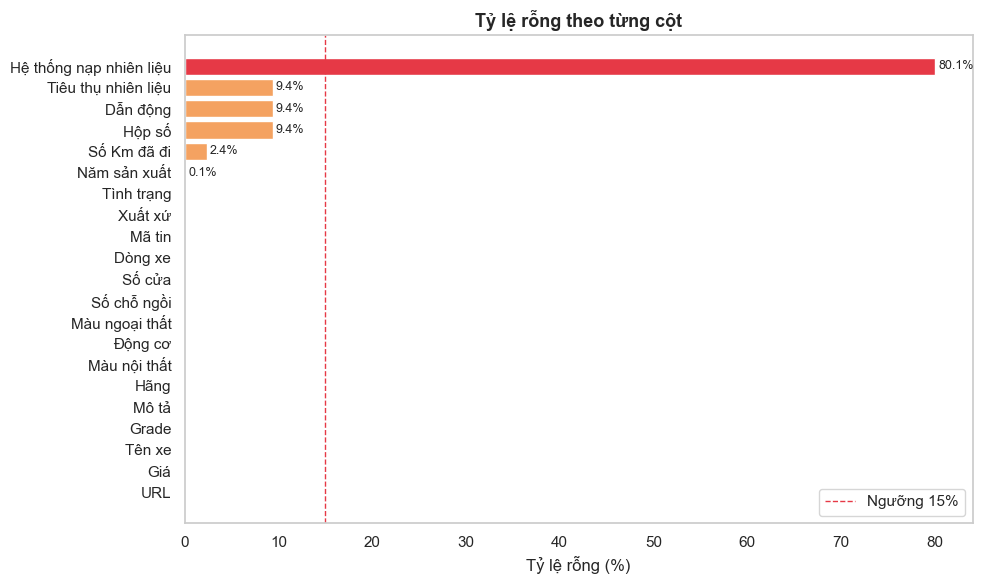

In [7]:
# Compute missing value statistics for each column
missing_stats = pd.DataFrame({
    "Cột"             : df.columns,
    "Dòng có giá trị" : df.notna().sum().values,
    "Dòng rỗng"       : df.isna().sum().values,
    "% Rỗng"          : (df.isna().mean().values * 100).round(2),
}).sort_values("% Rỗng", ascending=False).reset_index(drop=True)

print("Tỷ lệ rỗng toàn bộ 21 cột (sắp xếp giảm dần):")
display(missing_stats)

# Group columns by missing severity
zero_miss    = missing_stats[missing_stats["% Rỗng"] == 0]["Cột"].tolist()
low_miss     = missing_stats[(missing_stats["% Rỗng"] > 0) & (missing_stats["% Rỗng"] <= 15)]["Cột"].tolist()
high_miss    = missing_stats[missing_stats["% Rỗng"] > 15]["Cột"].tolist()

print(f"\nNhóm đầy đủ (0%)          : {len(zero_miss)} cột — {zero_miss}")
print(f"Nhóm thiếu thấp (0–15%)   : {len(low_miss)} cột — {low_miss}")
print(f"Nhóm thiếu cao (>15%)     : {len(high_miss)} cột — {high_miss}")

# Bar chart missing rate
fig, ax = plt.subplots(figsize=(10, 6))

colors = [
    "#e63946" if v > 15 else "#f4a261" if v > 0 else "#2a9d8f"
    for v in missing_stats["% Rỗng"]
]
bars = ax.barh(missing_stats["Cột"], missing_stats["% Rỗng"], color=colors)

for bar, val in zip(bars, missing_stats["% Rỗng"]):
    if val > 0:
        ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
                f"{val:.1f}%", va="center", fontsize=9)

ax.set_xlabel("Tỷ lệ rỗng (%)")
ax.set_title("Tỷ lệ rỗng theo từng cột", fontsize=13, fontweight="bold")
ax.invert_yaxis()
ax.axvline(x=15, color="#e63946", linestyle="--", linewidth=1, label="Ngưỡng 15%")
ax.legend()
ax.grid(False)
plt.tight_layout()
plt.show()

**Nhận xét:**
* **Nhóm cột đầy đủ:** Tập dữ liệu gồm *12 cột hoàn toàn đầy đủ* (0% rỗng), bao gồm toàn bộ các trường phân loại quan trọng như `Hãng`, `Dòng xe`, `Tình trạng`, `Xuất xứ`, `Màu ngoại thất`, `Màu nội thất` và cả trường định danh `Mã tin`, `URL`. Đây là nhóm cột tin cậy nhất để làm slicer và trục lọc trong Power BI.

* **Nhóm thiếu thấp (0 – 15%):** `Số Km đã đi` thiếu 2.35% (796 dòng) và `Năm sản xuất` thiếu 0.09% (32 dòng). Đây là mức thiếu chấp nhận được, xử lý bằng cách điền giá trị mặc định hoặc giữ nguyên null và lọc ra khi tính KPI liên quan.

* **Nhóm thiếu cao (>15%):** Gồm ba cột cùng rỗng 9.44% (`Hộp số`, `Dẫn động`, `Tiêu thụ nhiên liệu`) và một cột cực kỳ thiếu là `Hệ thống nạp nhiên liệu` với *80.07%* rỗng. Nguyên nhân là ba cột đầu liên kết logic trong form đăng tin, người đăng bỏ qua một trường sẽ khiến cả ba trống. Cột `Hệ thống nạp nhiên liệu` quá thưa nên không nên dùng làm slicer chính trong dashboard.

* **Nhận xét biểu đồ:** Biểu đồ trực quan hoá rõ sự phân cực giữa nhóm cột đầy đủ (màu xanh) và cột rỗng cao (màu đỏ), giúp người đọc nhanh chóng nhận diện trường nào cần ưu tiên xử lý trước khi mô hình hoá dữ liệu.

<a id="5-categorical-field-exploration"></a>

## **5. Categorical Field Exploration**

**Nội dung:**
Khảo sát phân bố chi tiết của các biến phân loại phục vụ cho Tab 4: Chân Dung Người Mua trong dashboard: màu ngoại thất, màu nội thất, hộp số, dẫn động và số chỗ ngồi. Tái sử dụng hàm `top_categories()` đã định nghĩa ở section 3.1.

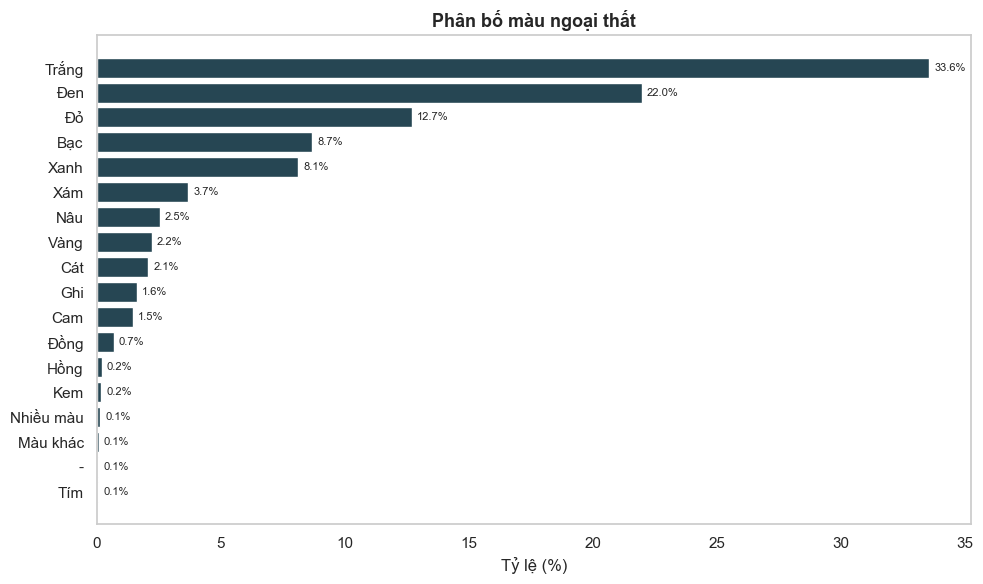

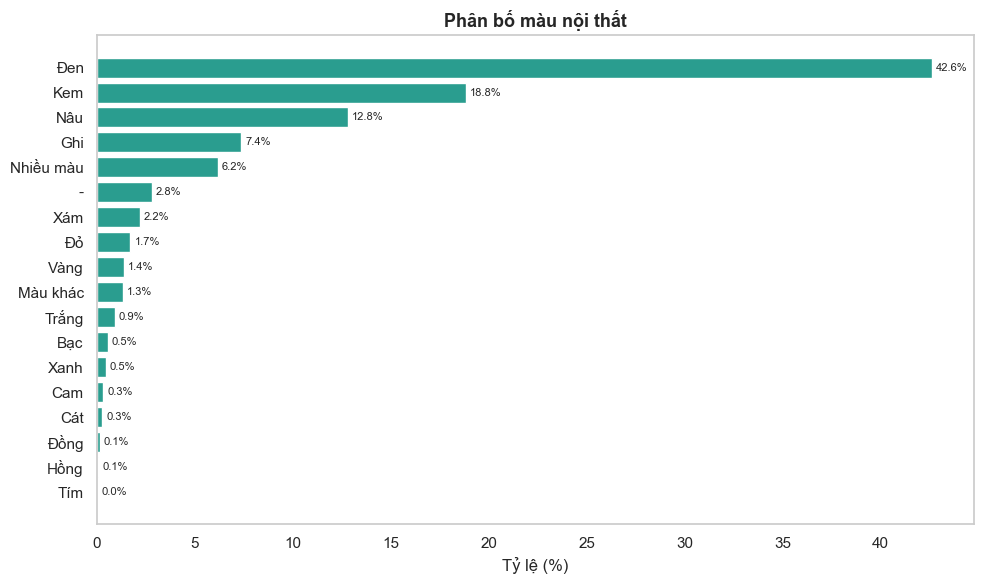

Phân bố Hộp số:


,Hộp số,Số tin,Tỷ_lệ
0,Số tự động,25136,74.26
1,Số tay,5499,16.25
2,Không rõ,3196,9.44
3,-,15,0.04
4,Số hỗn hợp,2,0.01



Phân bố Dẫn động:


,Dẫn động,Số tin,Tỷ_lệ
0,FWD - Dẫn động cầu trước,16445,48.58
1,RFD - Dẫn động cầu sau,7176,21.20
2,AWD - 4 bánh toàn thời gian,4514,13.34
3,Không rõ,3196,9.44
4,4WD - Dẫn động 4 bánh,2402,7.10
5,-,107,0.32
6,4WD hoặc AWD,8,0.02



Phân bố số chỗ ngồi (đã làm sạch):


,Số chỗ ngồi,Số tin,Tỷ lệ (%)
0,2,455,1.34
1,3,337,1.00
2,4,827,2.44
3,5,23294,68.82
4,6,182,0.54
5,7,6616,19.55
6,8,1816,5.37
7,9,34,0.10
8,10,38,0.11
9,11,1,0.00


In [8]:
# Color palette consistent across charts
BAR_COLOR = "#264653"

# Exterior color
ext_color = top_categories(df, "Màu ngoại thất", 18)
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(ext_color["Màu ngoại thất"][::-1], ext_color["Tỷ_lệ"][::-1], color=BAR_COLOR)
ax.set_xlabel("Tỷ lệ (%)")
ax.set_title("Phân bố màu ngoại thất", fontsize=13, fontweight="bold")
for i, (_, row) in enumerate(ext_color[::-1].iterrows()):
    ax.text(row["Tỷ_lệ"] + 0.2, i, f'{row["Tỷ_lệ"]:.1f}%', va="center", fontsize=8)
ax.grid(False) 
plt.tight_layout()
plt.show()

# Interior color
int_color = top_categories(df, "Màu nội thất", 18)
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(int_color["Màu nội thất"][::-1], int_color["Tỷ_lệ"][::-1], color="#2a9d8f")
ax.set_xlabel("Tỷ lệ (%)")
ax.set_title("Phân bố màu nội thất", fontsize=13, fontweight="bold")
for i, (_, row) in enumerate(int_color[::-1].iterrows()):
    ax.text(row["Tỷ_lệ"] + 0.2, i, f'{row["Tỷ_lệ"]:.1f}%', va="center", fontsize=8)
ax.grid(False) 
plt.tight_layout()
plt.show()

# Transmission
trans = top_categories(df, "Hộp số", 5)
print("Phân bố Hộp số:")
display(trans)

# Drivetrain
drive = top_categories(df, "Dẫn động", 7)
print("\nPhân bố Dẫn động:")
display(drive)

# Seat count (from processed data)
seat_counts = (
    df_proc["Số chỗ ngồi sạch"]
    .dropna()
    .astype(int)
    .value_counts()
    .sort_index()
    .reset_index()
)
seat_counts.columns = ["Số chỗ ngồi", "Số tin"]
seat_counts["Tỷ lệ (%)"] = (seat_counts["Số tin"] / len(df_proc) * 100).round(2)
print("\nPhân bố số chỗ ngồi (đã làm sạch):")
display(seat_counts)

**Nhận xét:**
* **Màu ngoại thất:** Trắng chiếm ưu thế tuyệt đối với *33.56%* (11,358 tin), tiếp theo là Đen *21.98%* và Đỏ *12.69%*. Ba màu này chiếm *68.23%* tổng thị trường, cho thấy người mua xe Việt Nam có xu hướng ưa chuộng màu trung tính và dễ bán lại. Các màu cá tính như Cam (1.46%), Hồng (0.20%), Tím (0.05%) chiếm thị phần rất nhỏ.

* **Màu nội thất:** Đen là màu nội thất phổ biến nhất với *42.64%* (14,432 tin), tiếp theo là Kem *18.83%* và Nâu *12.81%*. Đặc biệt, màu nội thất có mức độ đa dạng thấp hơn màu ngoại thất, ba màu đứng đầu đã chiếm tới *74.28%*.

* **Hộp số:** Số tự động chiếm *74.26%* (25,136 tin), số tay chỉ còn *16.25%* (5,499 tin). Xu hướng dịch chuyển sang hộp số tự động rõ ràng trong cơ cấu thị trường, phù hợp với bối cảnh các hãng gần như loại bỏ số tay khỏi dòng xe phổ thông từ sau 2020.

* **Dẫn động:** FWD (dẫn động cầu trước) chiếm đa số với *48.58%*, tiếp theo là RWD (21.20%) và AWD (13.34%). 4WD chiếm 7.10% chủ yếu từ các dòng xe bán tải và SUV địa hình.

* **Số chỗ ngồi:** Xe 5 chỗ chiếm *68.82%* (23,294 tin) và xe 7 chỗ xếp thứ hai với *19.55%* (6,616 tin). Hai loại này cộng lại chiếm *88.37%* thị trường, phản ánh nhu cầu gia đình là phân khúc chủ đạo tại Việt Nam. Các giá trị 16 chỗ (0.46%) và 10 chỗ (0.11%) thuộc nhóm xe thương mại và minibus.

<a id="6-numerical-fields-outlier-detection"></a>

## **6. Numerical Fields & Outlier Detection**

Phân tích thống kê mô tả và nhận diện outlier cho các trường số liệu chính: giá xe (`Giá (triệu VND)`), số km đã đi (`Số Km đã đi sạch`), dung tích động cơ (`Dung tích động cơ (lít)`), tiêu thụ nhiên liệu (`Tiêu thụ nhiên liệu sạch`) và năm sản xuất (`Năm sản xuất`). Outlier được xác định theo phương pháp IQR fence (ngưỡng 1.5×IQR), kết quả phục vụ trực tiếp cho Tab 2 và Tab 5 trong dashboard.

Thống kê mô tả và phát hiện outlier (phương pháp 1.5×IQR):


,Dòng hợp lệ,Dòng rỗng,Nhỏ nhất,Trung vị (P50),Trung bình,Lớn nhất,P25,P75,IQR,Upper fence,Outlier (>fence)
Cột,,,,,,,,,,,
Giá (triệu VND),33848,0,18.00,638.00,"1,201.60","54,000.00",425.00,"1,087.00",662.00,"2,080.00",4212
Số Km đã đi sạch,32792,1056,0.00,"20,000.00","35,802.50","500,000.00",0.00,"58,000.00","58,000.00","145,000.00",1004
Dung tích động cơ (lít),32013,1835,0.10,2.00,2.00,18.00,1.50,2.30,0.80,3.50,1665
Tiêu thụ nhiên liệu sạch,11355,22493,1.00,7.00,7.20,20.00,6.00,8.00,2.00,11.00,460
Năm sản xuất,33816,32,"1,990.00","2,019.00","2,018.00","2,025.00","2,015.00","2,022.00",7.00,"2,032.50",0


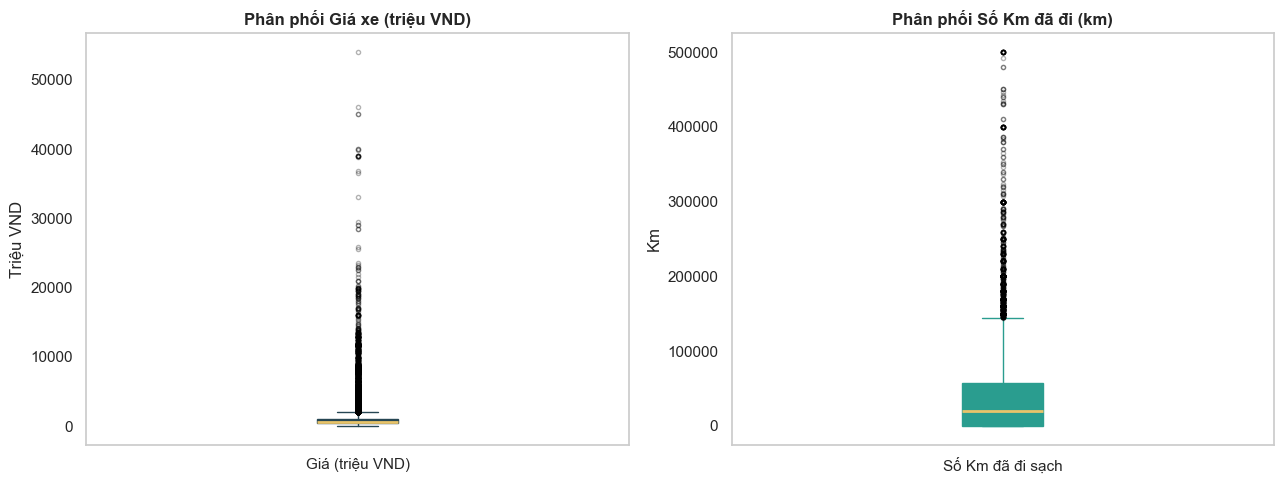


Top 10 dung tích động cơ phổ biến nhất:


,Dung tích (lít),Số tin
0,1.25,881
1,1.40,1330
2,1.50,5710
3,1.60,1960
4,1.80,1240
5,2.00,8533
6,2.20,1812
7,2.40,1407
8,2.50,2058
9,3.00,1516



Xe đắt nhất:


,Tên xe,Giá (triệu VND),Hãng,Năm sản xuất
0,Xe Ferrari SF90 Stradale 4.0 V8 2020,"54,000.00",Ferrari,"2,020.00"


Xe rẻ nhất:


,Tên xe,Giá (triệu VND),Hãng,Năm sản xuất
0,Xe Kia Pride Beta 1996,18.00,Kia,"1,996.00"


In [9]:
# Numerical columns of interest (all from processed data)
num_cols = {
    "Giá (triệu VND)"            : df_proc["Giá (triệu VND)"],
    "Số Km đã đi sạch"           : df_proc["Số Km đã đi sạch"],
    "Dung tích động cơ (lít)"    : df_proc["Dung tích động cơ (lít)"],
    "Tiêu thụ nhiên liệu sạch"   : df_proc["Tiêu thụ nhiên liệu sạch"],
    "Năm sản xuất"               : df_proc["Năm sản xuất"],
}

# Descriptive statistics table
desc_rows = []
for name, series in num_cols.items():
    s = series.dropna()
    q25, q75 = s.quantile(0.25), s.quantile(0.75)
    iqr       = q75 - q25
    upper     = q75 + 1.5 * iqr
    desc_rows.append({
        "Cột"             : name,
        "Dòng hợp lệ"     : len(s),
        "Dòng rỗng"       : series.isna().sum(),
        "Nhỏ nhất"        : round(s.min(), 1),
        "Trung vị (P50)"  : round(s.median(), 1),
        "Trung bình"      : round(s.mean(), 1),
        "Lớn nhất"        : round(s.max(), 1),
        "P25"             : round(q25, 1),
        "P75"             : round(q75, 1),
        "IQR"             : round(iqr, 1),
        "Upper fence"     : round(upper, 1),
        "Outlier (>fence)": int((s > upper).sum()),
    })

desc_df = pd.DataFrame(desc_rows).set_index("Cột")
print("Thống kê mô tả và phát hiện outlier (phương pháp 1.5×IQR):")
display(desc_df)

# Boxplot for price and km
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

df_proc["Giá (triệu VND)"].dropna().plot(
    kind="box", ax=axes[0], vert=True, patch_artist=True,
    boxprops=dict(facecolor="#264653", color="#264653"),
    medianprops=dict(color="#e9c46a", linewidth=2),
    whiskerprops=dict(color="#264653"),
    capprops=dict(color="#264653"),
    flierprops=dict(marker="o", color="#e63946", alpha=0.3, markersize=3),
)
axes[0].set_title("Phân phối Giá xe (triệu VND)", fontweight="bold")
axes[0].set_ylabel("Triệu VND")

df_proc["Số Km đã đi sạch"].dropna().plot(
    kind="box", ax=axes[1], vert=True, patch_artist=True,
    boxprops=dict(facecolor="#2a9d8f", color="#2a9d8f"),
    medianprops=dict(color="#e9c46a", linewidth=2),
    whiskerprops=dict(color="#2a9d8f"),
    capprops=dict(color="#2a9d8f"),
    flierprops=dict(marker="o", color="#e63946", alpha=0.3, markersize=3),
)
axes[1].set_title("Phân phối Số Km đã đi (km)", fontweight="bold")
axes[1].set_ylabel("Km")

axes[0].grid(False)   
axes[1].grid(False)   

plt.tight_layout()
plt.show()

# Engine displacement distribution (top 10)
eng_top = (
    df_proc["Dung tích động cơ (lít)"]
    .dropna()
    .value_counts()
    .head(10)
    .sort_index()
    .reset_index()
)
eng_top.columns = ["Dung tích (lít)", "Số tin"]
print("\nTop 10 dung tích động cơ phổ biến nhất:")
display(eng_top)

# Price extremes
max_row = df_proc.loc[df_proc["Giá (triệu VND)"].idxmax(),
                      ["Tên xe", "Giá (triệu VND)", "Hãng", "Năm sản xuất"]]
min_row = df_proc.loc[df_proc["Giá (triệu VND)"].idxmin(),
                      ["Tên xe", "Giá (triệu VND)", "Hãng", "Năm sản xuất"]]
print("\nXe đắt nhất:")
display(max_row.to_frame().T.reset_index(drop=True))
print("Xe rẻ nhất:")
display(min_row.to_frame().T.reset_index(drop=True))

**Nhận xét:**
* **Giá xe (triệu VND):** Phân phối lệch phải rất mạnh. Trung vị 638 triệu nhưng trung bình 1,202 triệu vì bị kéo bởi nhóm xe siêu sang. Theo phương pháp IQR fence (ngưỡng 1.5 × IQR = 2,080 triệu), có *4,212 tin* (12.4%) là outlier, chủ yếu là xe nhập khẩu cao cấp và siêu xe hợp lệ về mặt nghiệp vụ. Mọi KPI về giá trong dashboard nên dùng *trung vị* thay vì trung bình để đại diện đúng thị trường.

* **Số Km đã đi:** Trung vị 20,000 km, nhưng có 1,004 xe đi hơn 145,000 km (outlier theo IQR). Đặc biệt, có xe đạt 500,000 km, hoàn toàn có thể xảy ra với xe tải hoặc xe đầu kéo. 10,564 dòng ghi nhận "0 Km" là xe mới chưa lăn bánh, không phải lỗi dữ liệu. 1,056 dòng null cần loại ra khi phân tích km.

* **Dung tích động cơ:** Khoảng phổ biến từ 1.5L đến 2.5L, tập trung nhất ở 2.0L (*26.65%*, 8,533 xe) và 1.5L (*17.84%*, 5,710 xe). Giá trị cực đại 18.0L thuộc các xe thương mại hạng nặng. 1,835 dòng null (5.4%) do xe điện không có dung tích động cơ đốt trong.

* **Tiêu thụ nhiên liệu:** Trung vị 7.0 L/100km, tương đương mức tiêu thụ trung bình của xe phổ thông tại Việt Nam. Tuy nhiên, cột này có *22,493 dòng null* (66.5%), chủ yếu do xe điện (không có mức tiêu thụ nhiên liệu) và người đăng tin không nhập trường này. Không nên dùng cột này làm KPI chính trên dashboard.

* **Năm sản xuất:** Trải dài từ 1990 đến 2025, trung vị 2019, nghĩa là một nửa tập dữ liệu là xe sản xuất từ 2019 trở về sau. Chỉ 32 dòng null (0.09%) nên đây là trường gần như hoàn chỉnh.

<a id="7-fuel-type-trend-analysis"></a>

## **7. Fuel Type Trend Analysis**

Phân tích phân bố các loại nhiên liệu trong tập dữ liệu và xu hướng thay đổi theo năm sản xuất, đặc biệt tập trung vào sự tăng trưởng của xe điện và xe hybrid từ 2018 đến 2025. So sánh giá trung vị giữa các loại nhiên liệu và làm rõ vai trò của từng thương hiệu trong phân khúc xe điện. Kết quả phục vụ trực tiếp Tab 3: Xăng vs Điện trong dashboard.

Phân bố loại nhiên liệu:


,Loại nhiên liệu,Số tin,Tỷ lệ (%)
0,Xăng,26668,78.79
1,Dầu,5886,17.39
2,Điện,768,2.27
3,Hybrid,502,1.48
4,Không rõ,24,0.07



Xu hướng xe điện và hybrid theo năm sản xuất (2018–2025):


,Năm,Tổng tin,Xe điện,% Điện,Xe hybrid,% Hybrid
0,2018,2369,0,0.00,5,0.21
1,2019,2914,0,0.00,6,0.21
2,2020,2585,5,0.19,27,1.04
3,2021,2753,6,0.22,46,1.67
4,2022,3737,134,3.59,57,1.53
5,2023,4006,152,3.79,79,1.97
6,2024,1599,155,9.69,67,4.19
7,2025,1597,316,19.79,181,11.33


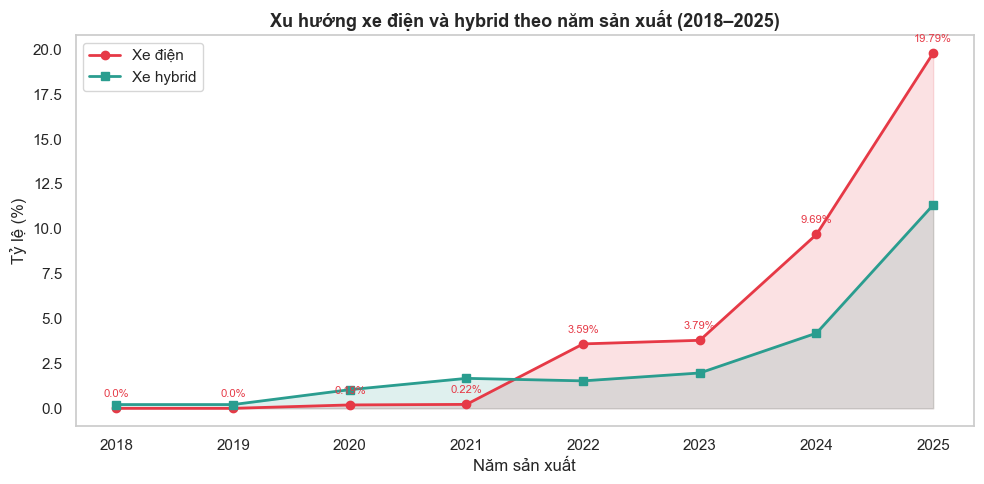


Giá trung vị theo loại nhiên liệu:


,Trung_vị,Trung_bình,Số_tin
Loại nhiên liệu,,,
Hybrid,"1,674.00","2,472.60",502
Dầu,716.00,785.10,5886
Điện,660.00,939.80,768
Xăng,600.00,"1,277.50",26668
Không rõ,387.50,716.50,24



Tổng xe điện: 768 tin
Top 10 thương hiệu xe điện:


,Hãng,Số tin,Tỷ lệ trong xe điện (%)
0,Vinfast,684,89.10
1,Mercedes Benz,19,2.50
2,Porsche,15,2.00
3,Ford,13,1.70
4,Byd,8,1.00
5,Geely,6,0.80
6,Volvo,4,0.50
7,Bestune,4,0.50
8,Hongqi,3,0.40
9,Audi,3,0.40


In [13]:
# Overall fuel type distribution
fuel_dist = (
    df_proc["Loại nhiên liệu"]
    .fillna("Không rõ")
    .value_counts()
    .reset_index()
)
fuel_dist.columns = ["Loại nhiên liệu", "Số tin"]
fuel_dist["Tỷ lệ (%)"] = (fuel_dist["Số tin"] / len(df_proc) * 100).round(2)
print("Phân bố loại nhiên liệu:")
display(fuel_dist)

# Trend of electric and hybrid by year (2018-2025)
df_yr = df_proc[df_proc["Năm sản xuất"].between(2018, 2025)].copy()
df_yr["Năm sản xuất"] = df_yr["Năm sản xuất"].astype(int)

trend_rows = []
for yr in sorted(df_yr["Năm sản xuất"].unique()):
    sub    = df_yr[df_yr["Năm sản xuất"] == yr]
    total  = len(sub)
    elec   = (sub["Loại nhiên liệu"] == "Điện").sum()
    hybrid = sub["Loại nhiên liệu"].str.contains("Hybrid", na=False).sum()
    trend_rows.append({
        "Năm"           : yr,
        "Tổng tin"      : total,
        "Xe điện"       : elec,
        "% Điện"        : round(elec   / total * 100, 2),
        "Xe hybrid"     : hybrid,
        "% Hybrid"      : round(hybrid / total * 100, 2),
    })
trend_df = pd.DataFrame(trend_rows)
print("\nXu hướng xe điện và hybrid theo năm sản xuất (2018–2025):")
display(trend_df)

# Line chart: % electric by year
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(trend_df["Năm"], trend_df["% Điện"],  marker="o", color="#e63946", linewidth=2, label="Xe điện")
ax.plot(trend_df["Năm"], trend_df["% Hybrid"], marker="s", color="#2a9d8f", linewidth=2, label="Xe hybrid")
ax.fill_between(trend_df["Năm"], trend_df["% Điện"],  alpha=0.15, color="#e63946")
ax.fill_between(trend_df["Năm"], trend_df["% Hybrid"], alpha=0.15, color="#2a9d8f")
for _, row in trend_df.iterrows():
    ax.annotate(f'{row["% Điện"]}%',  (row["Năm"], row["% Điện"]),
                textcoords="offset points", xytext=(0, 8), ha="center", fontsize=8, color="#e63946")
ax.set_xlabel("Năm sản xuất")
ax.set_ylabel("Tỷ lệ (%)")
ax.set_title("Xu hướng xe điện và hybrid theo năm sản xuất (2018–2025)", fontsize=13, fontweight="bold")
ax.legend()
ax.grid(False)
ax.set_xticks(trend_df["Năm"])
plt.tight_layout()
plt.show()

# Median price by fuel type
price_fuel = (
    df_proc.groupby("Loại nhiên liệu")["Giá (triệu VND)"]
           .agg(Trung_vị="median", Trung_bình="mean", Số_tin="count")
           .sort_values("Trung_vị", ascending=False)
           .round(1)
)
print("\nGiá trung vị theo loại nhiên liệu:")
display(price_fuel)

# Electric brand breakdown
elec_df = df_proc[df_proc["Loại nhiên liệu"] == "Điện"]
# Normalize VinFast naming
elec_df = elec_df.copy()
elec_df["Hãng"] = elec_df["Hãng"].str.strip().str.title()
elec_brand = elec_df["Hãng"].value_counts().head(10).reset_index()
elec_brand.columns = ["Hãng", "Số tin"]
elec_brand["Tỷ lệ trong xe điện (%)"] = (elec_brand["Số tin"] / len(elec_df) * 100).round(1)
print(f"\nTổng xe điện: {len(elec_df):,} tin")
print("Top 10 thương hiệu xe điện:")
display(elec_brand)

**Nhận xét:**

- **Cơ cấu nhiên liệu hiện tại:** Xăng vẫn chiếm ưu thế tuyệt đối với *78.79%* (26,668 tin), tiếp theo là Dầu *17.39%* (5,886 tin). Xe điện chỉ chiếm *2.27%* (768 tin) và Hybrid *1.48%* (502 tin), tỷ lệ nhỏ nhưng tốc độ tăng trưởng theo năm cho thấy xu hướng chuyển dịch đang diễn ra rõ nét.

- **Tốc độ tăng trưởng xe điện:** Từ 2018 đến 2021, tỷ lệ xe điện gần như bằng 0 (dưới 0.3% mỗi năm). Bước ngoặt xảy ra vào *2022* khi VinFast tung ra các mẫu VF 5, VF 8, VF 9 và tỷ lệ xe điện nhảy lên *3.59%*. Đến *2025*, tỷ lệ này đạt *19.79%* (316 trên 1,597 tin), tức cứ 5 xe sản xuất năm 2025 thì gần 1 chiếc là xe điện. Hybrid cũng tăng mạnh từ 0.21% năm 2018 lên *11.33%* năm 2025.

- **Giá trung vị theo loại nhiên liệu:** Hybrid có giá trung vị cao nhất với *1,674 triệu*, phản ánh việc công nghệ này chủ yếu xuất hiện ở phân khúc cao cấp (Toyota Lexus, Porsche). Xe điện có trung vị *660 triệu*, gần với xe xăng (*600 triệu*), cho thấy xe điện phổ thông (VinFast VF 5, VF 3) đã kéo mức giá xuống đáng kể so với kỳ vọng ban đầu.

- **Thị phần trong xe điện:** VinFast chiếm *89.1%* xe điện (684/768 tin, sau khi gộp các biến thể tên). Đây là minh chứng rõ ràng rằng thị trường xe điện tại Việt Nam hiện nay gần như là cuộc chơi độc lập của VinFast. Phần còn lại phần lớn là xe nhập khẩu cao cấp như Mercedes-Benz EQ (19 tin), Porsche Taycan (15 tin), Ford Mustang Mach-E (13 tin).


<a id="8-dashboard-kpi-pre-validation"></a>

## **8. Dashboard KPI Pre-Validation**

Xác nhận tính khả thi về số liệu của toàn bộ KPI được thiết kế trong 5 tab dashboard, thông qua việc tính toán trực tiếp giá trị và fill rate của cột nguồn tương ứng. Mọi KPI có fill rate dưới 80% cần được ghi chú giới hạn khi hiển thị trên Power BI.

In [11]:
# Validate KPI source columns for all 5 dashboard tabs
kpi_definitions = {
    "Tab 1: Bức Tranh Thị Trường": [
        ("Tổng tin đăng",      "Mã tin",               "count"),
        ("Tổng hãng xe",       "Hãng",                 "nunique"),
        ("Giá trung vị",       "Giá (triệu VND)",      "median"),
        ("% Xe mới",           "Tình trạng",           "pct_new"),
        ("% Xe nội địa",       "Xuất xứ",              "pct_domestic"),
    ],
    "Tab 2: Giải Mã Giá Xe": [
        ("Giá thấp nhất",      "Giá (triệu VND)",      "min"),
        ("Giá cao nhất",       "Giá (triệu VND)",      "max"),
        ("Giá trung vị",       "Giá (triệu VND)",      "median"),
        ("Hãng đủ điều kiện",  "Hãng",                 "brand_ge5"),
    ],
    "Tab 3: Xăng vs Điện": [
        ("Số loại nhiên liệu", "Loại nhiên liệu",      "nunique"),
        ("% Xe điện",          "Loại nhiên liệu",      "pct_elec"),
        ("% Xe xăng",          "Loại nhiên liệu",      "pct_petrol"),
        ("Giá trung vị điện",  "Giá (triệu VND)",      "median_elec"),
    ],
    "Tab 4: Chân Dung Người Mua": [
        ("Màu ngoại thất #1",  "Màu ngoại thất",       "top1"),
        ("Màu nội thất #1",    "Màu nội thất",         "top1"),
        ("Hộp số phổ biến",    "Hộp số",               "top1"),
        ("Số chỗ phổ biến",    "Số chỗ ngồi sạch",     "top1"),
    ],
    "Tab 5: Góc Khuất Thị Trường": [
        ("Xe đắt nhất",        "Giá (triệu VND)",      "max"),
        ("Km cao nhất",        "Số Km đã đi sạch",     "max"),
        ("Model phổ biến nhất","Grade",                 "top1"),
        ("Hãng dẫn đầu",       "Hãng",                 "top1"),
    ],
}

rows = []
for tab, kpis in kpi_definitions.items():
    for kpi_name, col, agg in kpis:
        fill_rate = df_proc[col].notna().mean() * 100 if col in df_proc.columns else 0
        series    = df_proc[col].dropna() if col in df_proc.columns else pd.Series()

        if   agg == "count"       : val = f"{len(df_proc):,}"
        elif agg == "nunique"     : val = f"{series.nunique():,}"
        elif agg == "median"      : val = f"{series.median():,.0f} triệu"
        elif agg == "mean"        : val = f"{series.mean():,.1f}"
        elif agg == "min"         : val = f"{series.min():,.0f} triệu"
        elif agg == "max"         : val = f"{series.max():,.0f}"
        elif agg == "top1"        : val = f"{series.mode().iloc[0]}"
        elif agg == "pct_new"     : val = f"{(df_proc['Tình trạng']=='Xe mới').mean()*100:.1f}%"
        elif agg == "pct_domestic": val = f"{(df_proc['Xuất xứ']=='Lắp ráp trong nước').mean()*100:.1f}%"
        elif agg == "pct_elec"    : val = f"{(df_proc['Loại nhiên liệu']=='Điện').mean()*100:.2f}%"
        elif agg == "pct_petrol"  : val = f"{(df_proc['Loại nhiên liệu']=='Xăng').mean()*100:.2f}%"
        elif agg == "median_elec" :
            val = f"{df_proc[df_proc['Loại nhiên liệu']=='Điện']['Giá (triệu VND)'].median():,.0f} triệu"
        elif agg == "brand_ge5"   :
            val = f"{(df_proc.groupby('Hãng').size() >= 5).sum():,} hãng"
        else: val = "N/A"

        status = "✓ Đủ" if fill_rate >= 80 else ("⚠ Thấp" if fill_rate >= 50 else "✗ Thiếu")
        rows.append({
            "Tab"          : tab,
            "KPI"          : kpi_name,
            "Cột nguồn"    : col,
            "Giá trị"      : val,
            "Fill Rate (%)" : round(fill_rate, 1),
            "Trạng thái"   : status,
        })

kpi_df = pd.DataFrame(rows)
print("Bảng kiểm tra KPI theo từng tab dashboard:")
display(kpi_df)

# Summary by tab
print("\nTóm tắt fill rate theo tab:")
for tab, grp in kpi_df.groupby("Tab"):
    low = grp[grp["Fill Rate (%)"] < 80]
    print(f"  {tab}: {len(grp)} KPI — {len(low)} KPI fill rate thấp")


Bảng kiểm tra KPI theo từng tab dashboard:


,Tab,KPI,Cột nguồn,Giá trị,Fill Rate (%),Trạng thái
0,Tab 1: Bức Tranh Thị Trường,Tổng tin đăng,Mã tin,"33,848",100.00,✓ Đủ
1,Tab 1: Bức Tranh Thị Trường,Tổng hãng xe,Hãng,91,100.00,✓ Đủ
2,Tab 1: Bức Tranh Thị Trường,Giá trung vị,Giá (triệu VND),638 triệu,100.00,✓ Đủ
3,Tab 1: Bức Tranh Thị Trường,% Xe mới,Tình trạng,20.3%,100.00,✓ Đủ
4,Tab 1: Bức Tranh Thị Trường,% Xe nội địa,Xuất xứ,58.0%,100.00,✓ Đủ
5,Tab 2: Giải Mã Giá Xe,Giá thấp nhất,Giá (triệu VND),18 triệu,100.00,✓ Đủ
6,Tab 2: Giải Mã Giá Xe,Giá cao nhất,Giá (triệu VND),"54,000",100.00,✓ Đủ
7,Tab 2: Giải Mã Giá Xe,Giá trung vị,Giá (triệu VND),638 triệu,100.00,✓ Đủ
8,Tab 2: Giải Mã Giá Xe,Hãng đủ điều kiện,Hãng,63 hãng,100.00,✓ Đủ
9,Tab 3: Xăng vs Điện,Số loại nhiên liệu,Loại nhiên liệu,5,100.00,✓ Đủ



Tóm tắt fill rate theo tab:
  Tab 1: Bức Tranh Thị Trường: 5 KPI — 0 KPI fill rate thấp
  Tab 2: Giải Mã Giá Xe: 4 KPI — 0 KPI fill rate thấp
  Tab 3: Xăng vs Điện: 4 KPI — 0 KPI fill rate thấp
  Tab 4: Chân Dung Người Mua: 4 KPI — 0 KPI fill rate thấp
  Tab 5: Góc Khuất Thị Trường: 4 KPI — 0 KPI fill rate thấp


**Nhận xét:**

**Tình trạng chung:** Tất cả 20 KPI trên 5 tab dashboard đều có cột nguồn tồn tại và không có KPI nào ở trạng thái thiếu (fill rate dưới 50%).

**Tab 1 Bức tranh thị trường:** Tất cả 5 KPI đạt fill rate *100%*, bao gồm tổng tin (*33,848*), tổng hãng (*91*), giá trung vị (*638 triệu*), tỷ lệ xe mới (*20.3%*) và tỷ lệ xe nội địa (*58.0%*).

**Tab 2 Giải mã giá xe:** Cột `Giá (triệu VND)` đạt fill rate *100%*, khoảng giá trải từ 18 triệu đến 54,000 triệu, có *63 hãng* đủ điều kiện phân tích với tối thiểu 5 tin đăng.

**Tab 3 Xăng vs điện:** Cột `Loại nhiên liệu` đạt fill rate *100%*, xăng chiếm *78.79%*, xe điện *2.27%*, giá trung vị xe điện *660 triệu*, tất cả sẵn sàng hiển thị trực tiếp.

**Tab 4 Chân dung người mua:** Ba cột phân loại chính đạt fill rate *100%*, cột `Số chỗ ngồi sạch` đạt *99.8%*, các giá trị phổ biến nhất là Trắng (ngoại thất), Đen (nội thất), Số tự động và 5 chỗ ngồi.

**Tab 5 Góc khuất thị trường:** Cột `Số Km đã đi sạch` có fill rate *96.9%* (1,056 dòng null) cần ghi chú khi hiển thị trên dashboard, model phổ biến nhất là Ford *Ranger* và hãng dẫn đầu là *Toyota* với *17.32%* thị phần.

<a id="9-star-schema-architecture-review"></a>

## **9. Star Schema Architecture Review**

Xác nhận tính toàn vẹn của mô hình Star Schema đã xây dựng trong thư mục `data/processed/`. Kiểm tra tính duy nhất của khoá chính `Mã tin` trong bảng fact, liệt kê toàn bộ 11 bảng dimension kèm số dòng và khoá chính, đồng thời in ra sơ đồ quan hệ dạng text để tổng kết cấu trúc dữ liệu trước khi nhập vào Power BI.

In [12]:
# Verify fact table integrity
fact_df  = pd.read_csv(FACT_PATH, encoding="utf-8", low_memory=False)
pk_col   = "Mã tin"
n_rows   = len(fact_df)
n_unique = fact_df[pk_col].nunique()
is_unique = n_unique == n_rows

print(f"Bảng fact_car_listings:")
print(f"  Tổng dòng          : {n_rows:,}")
print(f"  Mã tin duy nhất    : {n_unique:,}")
print(f"  Khoá chính hợp lệ  : {is_unique}")
print(f"  Số cột             : {fact_df.shape[1]}")
print(f"  Danh sách cột fact :")
for c in fact_df.columns:
    print(f"    {c}")

# Dimension tables summary
dim_files = sorted(PROC_DIR.glob("dim_*.csv"))
dim_summary = []
for f in dim_files:
    d = pd.read_csv(f, encoding="utf-8", low_memory=False)
    dim_summary.append({
        "Tên bảng"    : f.stem,
        "Số dòng"     : len(d),
        "Số cột"      : d.shape[1],
        "Khoá chính"  : d.columns[0],
    })
dim_df = pd.DataFrame(dim_summary)
print("\nDanh sách bảng dimension:")
display(dim_df)

# Print schema relationship diagram
print("\nSơ đồ quan hệ Star Schema:")
print()
print("  fact_car_listings  (33,848 dòng  |  PK: Mã tin)")
print("        |")
for _, row in dim_df.iterrows():
    print(f"        +---> {row['Tên bảng']:<30}  ({row['Số dòng']:>4} dòng  |  PK: {row['Khoá chính']})")

Bảng fact_car_listings:
  Tổng dòng          : 33,848
  Mã tin duy nhất    : 33,831
  Khoá chính hợp lệ  : False
  Số cột             : 23
  Danh sách cột fact :
    id_tin_đăng
    URL
    Mã tin
    Tên xe
    Mô tả
    Năm sản xuất
    Giá (triệu VND)
    Số Km đã đi sạch
    Dung tích động cơ (lít)
    Tiêu thụ nhiên liệu sạch
    Số cửa sạch
    Số chỗ ngồi sạch
    id_xuất_xứ
    id_tình_trạng
    id_dòng_xe
    id_màu_ngoại_thất
    id_màu_nội_thất
    id_hệ_thống_nạp
    id_hộp_số
    id_dẫn_động
    id_loại_nhiên_liệu
    id_hãng
    id_phân_khúc

Danh sách bảng dimension:


,Tên bảng,Số dòng,Số cột,Khoá chính
0,dim_body_type,10,2,id_dòng_xe
1,dim_brand,91,2,id_hãng
2,dim_condition,2,2,id_tình_trạng
3,dim_drivetrain,6,2,id_dẫn_động
4,dim_exterior_color,18,2,id_màu_ngoại_thất
5,dim_fuel_injection,262,2,id_hệ_thống_nạp
6,dim_fuel_type,5,2,id_loại_nhiên_liệu
7,dim_grade,612,3,id_phân_khúc
8,dim_interior_color,18,2,id_màu_nội_thất
9,dim_origin,2,2,id_xuất_xứ



Sơ đồ quan hệ Star Schema:

  fact_car_listings  (33,848 dòng  |  PK: Mã tin)
        |
        +---> dim_body_type                   (  10 dòng  |  PK: id_dòng_xe)
        +---> dim_brand                       (  91 dòng  |  PK: id_hãng)
        +---> dim_condition                   (   2 dòng  |  PK: id_tình_trạng)
        +---> dim_drivetrain                  (   6 dòng  |  PK: id_dẫn_động)
        +---> dim_exterior_color              (  18 dòng  |  PK: id_màu_ngoại_thất)
        +---> dim_fuel_injection              ( 262 dòng  |  PK: id_hệ_thống_nạp)
        +---> dim_fuel_type                   (   5 dòng  |  PK: id_loại_nhiên_liệu)
        +---> dim_grade                       ( 612 dòng  |  PK: id_phân_khúc)
        +---> dim_interior_color              (  18 dòng  |  PK: id_màu_nội_thất)
        +---> dim_origin                      (   2 dòng  |  PK: id_xuất_xứ)
        +---> dim_transmission                (   4 dòng  |  PK: id_hộp_số)


**Nhận xét:**

**Tình trạng khoá chính bảng fact:** Bảng `fact_car_listings` chứa *33,848 dòng* nhưng chỉ có *33,831 giá trị `Mã tin` duy nhất*, tức còn 17 dòng trùng khoá chính chưa được loại bỏ trong bước preprocessing, cần chạy `Remove Duplicates` trên cột `Mã tin` trước khi nhập vào Power BI để đảm bảo quan hệ One-to-Many hoạt động chính xác.

**Cấu trúc 11 bảng dimension:** Mô hình gồm 11 bảng dimension, trong đó các bảng ngắn 2 dòng như `dim_condition`, `dim_origin` đóng vai trò slicer nhanh, các bảng trung bình như `dim_brand` (91 dòng), `dim_exterior_color` và `dim_interior_color` (18 dòng mỗi bảng) cho phép lọc theo danh mục, và `dim_grade` (612 dòng) là bảng lớn nhất lưu toàn bộ model xe theo phân khúc.

**Cột `Dung tích động cơ` và `Loại nhiên liệu`:** Hai cột này được lưu trực tiếp trong bảng fact thay vì tách ra bảng dimension riêng vì đây là thuộc tính đo lường liên tục, không phải danh mục cố định, nên không cần surrogate key.

**Sẵn sàng cho Power BI:** Sau khi xử lý 17 dòng trùng `Mã tin`, toàn bộ *13 file CSV* (1 fact, 11 dim, 1 processed tổng hợp) đã sẵn sàng import vào Power BI Desktop theo quy trình: Get Data, Text/CSV, định nghĩa quan hệ trong Model View và xây dựng DAX measures trên bảng fact.